In [1]:
# dependencies

from Bio import AlignIO
from Bio import SeqIO
import re
import pandas as pd
from ete3 import NCBITaxa
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import ast

In [2]:
# results in FASTA form into dataframe

def pfam_results(results_input):
    data = {'accession': [], 'taxon': [], 'seq identifier': [], 'I Helix': []}
    with open(results_input) as fp:
        for record in SeqIO.parse(fp, "fasta"):
            seqident = re.findall(r"\|(?P<sequence_id>\w+)\|", record.id)
            accession = record.description
            taxon = re.findall(r"OX=(\d+)", record.description)
            sequence = str(record.seq)

            # attaching to dictionary
            data['seq identifier'].append(", ".join(seqident))
            data['accession'].append(accession)
            data['taxon'].append(", ".join(taxon))
            data['I Helix'].append(sequence)

    df = pd.DataFrame.from_dict(data)
    return df

In [3]:
# Converting HMM search output for pfam data to FASTA file
input = '/home/alecia/chapter3-repo/output/hmm_search_2/pfam/3/ihelixhits_e_0p001_z__T_.aln'
outfile_fasta = '/home/alecia/chapter3-repo/output/hmm_search_2/pfam/3/ihelixhits_e_0p001_z__T_.fasta'

with open(input) as infile:
    alignment = AlignIO.read(infile, 'stockholm')

SeqIO.write(alignment, outfile_fasta, 'fasta')

278757

In [4]:
pfam_r1 = pfam_results('/home/alecia/chapter3-repo/output/hmm_search_1/pfam/3/ihelixhits_e_0p001_z__T_.fasta')
pfam_r2 = pfam_results('/home/alecia/chapter3-repo/output/hmm_search_2/pfam/3/ihelixhits_e_0p001_z__T_.fasta')

In [5]:
pfam_r1

,accession,taxon,seq identifier,I Helix
0,tr|A0A498MRP4|A0A498MRP4_LABRO/720-751 [subseq...,84645,A0A498MRP4,-DGLVIACL-DV-I-EA--G---TET--T--A-T--TLR-WGLLFMIKY
1,tr|A0A498MRP4|A0A498MRP4_LABRO/1166-1197 [subs...,84645,A0A498MRP4,-EGLVISCL-DV-I-EA--G---TET--T--A-T--TLR-WGLLFMIKY
2,tr|A0A498MRP4|A0A498MRP4_LABRO/1618-1649 [subs...,84645,A0A498MRP4,-DGLVIICL-DV-I-EA--G---TET--T--T-T--TLR-WGLLFMIKY
3,tr|A0A498MRP4|A0A498MRP4_LABRO/2174-2205 [subs...,84645,A0A498MRP4,-DGLVISCL-DV-I-EA--G---TET--T--A-T--TLR-WGLLFMIKY
4,tr|A0A498MRP4|A0A498MRP4_LABRO/2626-2657 [subs...,84645,A0A498MRP4,-DGLVISCL-DV-I-EA--G---SET--T--A-T--TLR-WGLLFMIKY
...,...,...,...,...
162079,tr|A0A2S3GQM6|A0A2S3GQM6_9POAL/311-340 [subseq...,206008,A0A2S3GQM6,---LRDFCI-SF-V-LA--G---RDT--S--S-V--ALA-WFFWLLASH
162080,tr|A0A8X7P7K3|A0A8X7P7K3_BRACI/295-322 [subseq...,52824,A0A8X7P7K3,-----RECK-LF-Y-FA--G---QET--T--S-V--LLV-WTMILLSHH
162081,tr|A0A7S8A7J9|A0A7S8A7J9_9BRAD/226-256 [subseq...,1325114,A0A7S8A7J9,-DEMVSMVF-LL-L-AA--G---SET--T--T-H--LIS-GSAYELLR-
162082,tr|A0A395IRT2|A0A395IRT2_9HELO/207-235 [subseq...,38457,A0A395IRT2,---ILANMI-TF-L-IA--G---HET--I--S-G--ILS-FVFLNLMK-


In [6]:
pfam_r2

,accession,taxon,seq identifier,I Helix
0,tr|A0A182XW67|A0A182XW67_ANOST/287-321 [subseq...,30069,A0A182XW67,LDMTQV--AGQCY-S-F-F-I--A----G------FE--T-SAS--...
1,tr|A0A182XW67|A0A182XW67_ANOST/819-853 [subseq...,30069,A0A182XW67,MTLNEL--AAQVF-I-F-F-L--A----G------FE--T-SST--...
2,tr|A0A182XW67|A0A182XW67_ANOST/1316-1351 [subs...,30069,A0A182XW67,LTMNEL--AAQVF-I-F-F-V--A----G------FE--T-SST--...
3,tr|A0A182XW67|A0A182XW67_ANOST/1825-1860 [subs...,30069,A0A182XW67,LTLNEL--AAQVF-V-F-F-L--A----G------FE--T-SST--...
4,tr|A0A182XW67|A0A182XW67_ANOST/2334-2369 [subs...,30069,A0A182XW67,LTHNEL--AAQVL-I-F-F-L--A----G------FE--T-SST--...
...,...,...,...,...
278752,tr|A0A1Y2UC39|A0A1Y2UC39_9PEZI/289-316 [subseq...,1001938,A0A1Y2UC39,---------MEAI-L-F-T-V--A----G------GD--T-TST--...
278753,tr|A0A1H4E4S6|A0A1H4E4S6_9BURK/238-270 [subseq...,83784,A0A1H4E4S6,LSEVEL--LQNCI-F-I-L-N--A----G------HE--T-TTN--...
278754,tr|A0A0E4FSG9|A0A0E4FSG9_9BRAD/239-274 [subseq...,1355477,A0A0E4FSG9,LSDAEL--ISMLW-G-M-L-L--G----G------FV--T-TAA--...
278755,tr|A0A210Q976|A0A210Q976_MIZYE/289-323 [subseq...,6573,A0A210Q976,FTDNNL--TTLIG-N-V-F-S--A----G------TE--T-TAT--...


In [7]:
r1r2_merged_pfam = (pd.merge(pfam_r1, pfam_r2, how='outer', on=['seq identifier', 'taxon'])
                    .fillna(0)
                    .drop_duplicates(subset=['seq identifier']))
r1r2_merged_pfam

,accession_x,taxon,seq identifier,I Helix_x,accession_y,I Helix_y
0,tr|A0A498MRP4|A0A498MRP4_LABRO/720-751 [subseq...,84645,A0A498MRP4,-DGLVIACL-DV-I-EA--G---TET--T--A-T--TLR-WGLLFMIKY,tr|A0A498MRP4|A0A498MRP4_LABRO/1164-1198 [subs...,-NMEGL--VISCL-D-V-I-E--A----G------TE--T-TAT--...
21,tr|A0A182Y3M0|A0A182Y3M0_ANOST/316-347 [subseq...,30069,A0A182Y3M0,-EEIAAQAF-VF-F-FG--G---FET--S--T-T--TLT-CALHLLAKY,tr|A0A182Y3M0|A0A182Y3M0_ANOST/313-348 [subseq...,LTFEEI--AAQAF-V-F-F-F--G----G------FE--T-STT--...
85,tr|A0A9Q0JPW7|A0A9Q0JPW7_9ROSI/567-595 [subseq...,218843,A0A9Q0JPW7,-RYLRDIIL-NI-M-FA--G---KDT--S--A-N--TIS-WFFYML---,tr|A0A9Q0JPW7|A0A9Q0JPW7_9ROSI/564-599 [subseq...,MNDRYL--RDIIL-N-I-M-F--A----G------KD--T-SAN--...
109,tr|A0A8J4WTT4|A0A8J4WTT4_CLAMG/475-505 [subseq...,1594786,A0A8J4WTT4,--DVYGSVA-EL-L-LA--G---VDT--T--S-I--TLM-WALYLLSQN,tr|A0A8J4WTT4|A0A8J4WTT4_CLAMG/471-506 [subseq...,MSKKDV--YGSVA-E-L-L-L--A----G------VD--T-TSI--...
145,tr|A0A553R2M7|A0A553R2M7_9TELE/301-332 [subseq...,623744,A0A553R2M7,-ENLMMTVM-NL-F-VA--G---TDT--T--G-T--TLR-WGLMLMAKY,tr|A0A553R2M7|A0A553R2M7_9TELE/300-333 [subseq...,--DENL--MMTVM-N-L-F-V--A----G------TD--T-TGT--...
...,...,...,...,...,...,...
294301,0,100035,A0A7C8I5D7,0,tr|A0A7C8I5D7|A0A7C8I5D7_9PLEO/294-325 [subseq...,----VL--RDQIV-Q-A-M-M--A----S------TE--T-TGS--...
294302,0,50452,A0A087GH04,0,tr|A0A087GH04|A0A087GH04_ARAAL/284-319 [subseq...,FTHENV--KSMIL-D-I-V-V--P----G------TD--T-AAA--...
294303,0,1001938,A0A1Y2UC39,0,tr|A0A1Y2UC39|A0A1Y2UC39_9PEZI/289-316 [subseq...,---------MEAI-L-F-T-V--A----G------GD--T-TST--...
294304,0,1355477,A0A0E4FSG9,0,tr|A0A0E4FSG9|A0A0E4FSG9_9BRAD/239-274 [subseq...,LSDAEL--ISMLW-G-M-L-L--G----G------FV--T-TAA--...


In [8]:
# If sequence in I_Helix y, take the acid alcohol - if not, take the acid alcohol in I Helix x

result_data = []

for index, row in r1r2_merged_pfam.iterrows():
    if row['I Helix_y'] != 0:
        acid = row['I Helix_y'][36]
        alc = row['I Helix_y'][39]
    else:
        acid = row['I Helix_x'][24]
        alc = row['I Helix_x'][25]

    # Append a dictionary with relevant information to the result_data list
    result_data.append({
        'accession': row['accession_y'],
        'sequence_y': row['I Helix_y'],
        'sequence_x': row['I Helix_x'],
        'seq identifier': row['seq identifier'],
        'acid': acid,
        'alc': alc,
        'taxon': row['taxon'],
    })


# Create a DataFrame from the result_data list
result_df = pd.DataFrame(result_data)


In [9]:
result_df

,accession,sequence_y,sequence_x,seq identifier,acid,alc,taxon
0,tr|A0A498MRP4|A0A498MRP4_LABRO/1164-1198 [subs...,-NMEGL--VISCL-D-V-I-E--A----G------TE--T-TAT--...,-DGLVIACL-DV-I-EA--G---TET--T--A-T--TLR-WGLLFMIKY,A0A498MRP4,E,T,84645
1,tr|A0A182Y3M0|A0A182Y3M0_ANOST/313-348 [subseq...,LTFEEI--AAQAF-V-F-F-F--G----G------FE--T-STT--...,-EEIAAQAF-VF-F-FG--G---FET--S--T-T--TLT-CALHLLAKY,A0A182Y3M0,E,T,30069
2,tr|A0A9Q0JPW7|A0A9Q0JPW7_9ROSI/564-599 [subseq...,MNDRYL--RDIIL-N-I-M-F--A----G------KD--T-SAN--...,-RYLRDIIL-NI-M-FA--G---KDT--S--A-N--TIS-WFFYML---,A0A9Q0JPW7,D,T,218843
3,tr|A0A8J4WTT4|A0A8J4WTT4_CLAMG/471-506 [subseq...,MSKKDV--YGSVA-E-L-L-L--A----G------VD--T-TSI--...,--DVYGSVA-EL-L-LA--G---VDT--T--S-I--TLM-WALYLLSQN,A0A8J4WTT4,D,T,1594786
4,tr|A0A553R2M7|A0A553R2M7_9TELE/300-333 [subseq...,--DENL--MMTVM-N-L-F-V--A----G------TD--T-TGT--...,-ENLMMTVM-NL-F-VA--G---TDT--T--G-T--TLR-WGLMLMAKY,A0A553R2M7,D,T,623744
...,...,...,...,...,...,...,...
287225,tr|A0A7C8I5D7|A0A7C8I5D7_9PLEO/294-325 [subseq...,----VL--RDQIV-Q-A-M-M--A----S------TE--T-TGS--...,0,A0A7C8I5D7,E,T,100035
287226,tr|A0A087GH04|A0A087GH04_ARAAL/284-319 [subseq...,FTHENV--KSMIL-D-I-V-V--P----G------TD--T-AAA--...,0,A0A087GH04,D,T,50452
287227,tr|A0A1Y2UC39|A0A1Y2UC39_9PEZI/289-316 [subseq...,---------MEAI-L-F-T-V--A----G------GD--T-TST--...,0,A0A1Y2UC39,D,T,1001938
287228,tr|A0A0E4FSG9|A0A0E4FSG9_9BRAD/239-274 [subseq...,LSDAEL--ISMLW-G-M-L-L--G----G------FV--T-TAA--...,0,A0A0E4FSG9,V,T,1355477


In [10]:
ncbi = NCBITaxa()

In [11]:
# Function to fetch lineage and ranks using NCBITaxa
def get_lineage_and_ranks(taxon_id):
    try:
        lineage = ncbi.get_lineage(taxon_id)  # List of lineage taxids
        ranks = ncbi.get_rank(lineage)  # Get ranks for the lineage
        
        # Map the taxid to its corresponding name and rank
        lineage_and_ranks = {ncbi.get_taxid_translator([taxid])[taxid]: ranks[taxid] 
                             for taxid in lineage if taxid in ranks}
        
        return lineage_and_ranks
    except:
        return None  # Return None if the ID is not found or there is an error

In [15]:
# Apply ncbi taxa to dataframe in chunks to access lineage and ranks

result_df["lineage_and_ranks"] = result_df["taxon"].apply(lambda x: get_lineage_and_ranks(int(x)) if pd.notna(x) else None)

/home/alecia/anaconda3/envs/taxon/lib/python3.9/site-packages/ete3/ncbi_taxonomy/ncbiquery.py:243: UserWarning: taxid 299123 was translated into 40157
  warnings.warn("taxid %s was translated into %s" %(taxid, merged_conversion[taxid]))
/home/alecia/anaconda3/envs/taxon/lib/python3.9/site-packages/ete3/ncbi_taxonomy/ncbiquery.py:243: UserWarning: taxid 59451 was translated into 3371016
  warnings.warn("taxid %s was translated into %s" %(taxid, merged_conversion[taxid]))
/home/alecia/anaconda3/envs/taxon/lib/python3.9/site-packages/ete3/ncbi_taxonomy/ncbiquery.py:243: UserWarning: taxid 322609 was translated into 85044
  warnings.warn("taxid %s was translated into %s" %(taxid, merged_conversion[taxid]))
/home/alecia/anaconda3/envs/taxon/lib/python3.9/site-packages/ete3/ncbi_taxonomy/ncbiquery.py:243: UserWarning: taxid 2052317 was translated into 3107663
  warnings.warn("taxid %s was translated into %s" %(taxid, merged_conversion[taxid]))
/home/alecia/anaconda3/envs/taxon/lib/python3.9/

In [16]:
result_df.to_csv('r1r2_pfam_acidalc_taxon.csv')

In [14]:
input = '/home/alecia/chapter3-repo/analysis/pfam_tax/r1r2_pfam_acidalc_taxon.csv'

with open(input) as f:
    pfam_with_taxa = pd.read_csv(input)

pfam_with_taxa

/home/alecia/anaconda3/envs/taxon/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3550: DtypeWarning: Columns (3) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


,Unnamed: 0,accession,sequence_y,sequence_x,seq identifier,acid,alc,taxon,lineage_and_ranks
0,0,tr|A0A498MRP4|A0A498MRP4_LABRO/1164-1198 [subs...,-NMEGL--VISCL-D-V-I-E--A----G------TE--T-TAT--...,-DGLVIACL-DV-I-EA--G---TET--T--A-T--TLR-WGLLFMIKY,A0A498MRP4,E,T,84645,"{'root': 'no rank', 'cellular organisms': 'no ..."
1,1,tr|A0A182Y3M0|A0A182Y3M0_ANOST/313-348 [subseq...,LTFEEI--AAQAF-V-F-F-F--G----G------FE--T-STT--...,-EEIAAQAF-VF-F-FG--G---FET--S--T-T--TLT-CALHLLAKY,A0A182Y3M0,E,T,30069,"{'root': 'no rank', 'cellular organisms': 'no ..."
2,2,tr|A0A9Q0JPW7|A0A9Q0JPW7_9ROSI/564-599 [subseq...,MNDRYL--RDIIL-N-I-M-F--A----G------KD--T-SAN--...,-RYLRDIIL-NI-M-FA--G---KDT--S--A-N--TIS-WFFYML---,A0A9Q0JPW7,D,T,218843,"{'root': 'no rank', 'cellular organisms': 'no ..."
3,3,tr|A0A8J4WTT4|A0A8J4WTT4_CLAMG/471-506 [subseq...,MSKKDV--YGSVA-E-L-L-L--A----G------VD--T-TSI--...,--DVYGSVA-EL-L-LA--G---VDT--T--S-I--TLM-WALYLLSQN,A0A8J4WTT4,D,T,1594786,"{'root': 'no rank', 'cellular organisms': 'no ..."
4,4,tr|A0A553R2M7|A0A553R2M7_9TELE/300-333 [subseq...,--DENL--MMTVM-N-L-F-V--A----G------TD--T-TGT--...,-ENLMMTVM-NL-F-VA--G---TDT--T--G-T--TLR-WGLMLMAKY,A0A553R2M7,D,T,623744,"{'root': 'no rank', 'cellular organisms': 'no ..."
...,...,...,...,...,...,...,...,...,...
287225,287225,tr|A0A7C8I5D7|A0A7C8I5D7_9PLEO/294-325 [subseq...,----VL--RDQIV-Q-A-M-M--A----S------TE--T-TGS--...,0,A0A7C8I5D7,E,T,100035,"{'root': 'no rank', 'cellular organisms': 'no ..."
287226,287226,tr|A0A087GH04|A0A087GH04_ARAAL/284-319 [subseq...,FTHENV--KSMIL-D-I-V-V--P----G------TD--T-AAA--...,0,A0A087GH04,D,T,50452,"{'root': 'no rank', 'cellular organisms': 'no ..."
287227,287227,tr|A0A1Y2UC39|A0A1Y2UC39_9PEZI/289-316 [subseq...,---------MEAI-L-F-T-V--A----G------GD--T-TST--...,0,A0A1Y2UC39,D,T,1001938,"{'root': 'no rank', 'cellular organisms': 'no ..."
287228,287228,tr|A0A0E4FSG9|A0A0E4FSG9_9BRAD/239-274 [subseq...,LSDAEL--ISMLW-G-M-L-L--G----G------FV--T-TAA--...,0,A0A0E4FSG9,V,T,1355477,"{'root': 'no rank', 'cellular organisms': 'no ..."


In [15]:
# Define standard taxonomic ranks
tax_ranks = ['kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species']

# Function to flip dict and extract ranks
def extract_taxonomy(tax_str):
    try:
        # Parse only if it's a string
        tax_dict = ast.literal_eval(tax_str) if isinstance(tax_str, str) else tax_str
        # Flip key-values: {'Metazoa': 'kingdom'} → {'kingdom': 'Metazoa'}
        flipped = {v.strip(): k.strip() for k, v in tax_dict.items()}
        # Extract ranks in the desired order
        return [flipped.get(rank, None) for rank in tax_ranks]
    except Exception as e:
        print(f"Error parsing: {tax_str}\n{e}")  # Debugging info
        return [None] * len(tax_ranks)

# Apply extraction function
pfam_with_taxa[tax_ranks] = pfam_with_taxa['lineage_and_ranks'].apply(lambda x: pd.Series(extract_taxonomy(x)))

# Save or view the result
pfam_with_taxa.to_csv('taxonomy_parsed.csv', index=False)
print(pfam_with_taxa.head())

   Unnamed: 0                                          accession  \
0           0  tr|A0A498MRP4|A0A498MRP4_LABRO/1164-1198 [subs...   
1           1  tr|A0A182Y3M0|A0A182Y3M0_ANOST/313-348 [subseq...   
2           2  tr|A0A9Q0JPW7|A0A9Q0JPW7_9ROSI/564-599 [subseq...   
3           3  tr|A0A8J4WTT4|A0A8J4WTT4_CLAMG/471-506 [subseq...   
4           4  tr|A0A553R2M7|A0A553R2M7_9TELE/300-333 [subseq...   

                                          sequence_y  \
0  -NMEGL--VISCL-D-V-I-E--A----G------TE--T-TAT--...   
1  LTFEEI--AAQAF-V-F-F-F--G----G------FE--T-STT--...   
2  MNDRYL--RDIIL-N-I-M-F--A----G------KD--T-SAN--...   
3  MSKKDV--YGSVA-E-L-L-L--A----G------VD--T-TSI--...   
4  --DENL--MMTVM-N-L-F-V--A----G------TD--T-TGT--...   

                                          sequence_x seq identifier acid alc  \
0  -DGLVIACL-DV-I-EA--G---TET--T--A-T--TLR-WGLLFMIKY     A0A498MRP4    E   T   
1  -EEIAAQAF-VF-F-FG--G---FET--S--T-T--TLT-CALHLLAKY     A0A182Y3M0    E   T   
2  -RYLRDIIL-N

In [17]:
pfam_with_taxa['acid_alc'] = pfam_with_taxa['acid'] + pfam_with_taxa['alc']

In [18]:
pfam_with_taxa.head()

,Unnamed: 0,accession,sequence_y,sequence_x,seq identifier,acid,alc,taxon,lineage_and_ranks,kingdom,phylum,class,order,family,genus,species,acid_alc
0,0,tr|A0A498MRP4|A0A498MRP4_LABRO/1164-1198 [subs...,-NMEGL--VISCL-D-V-I-E--A----G------TE--T-TAT--...,-DGLVIACL-DV-I-EA--G---TET--T--A-T--TLR-WGLLFMIKY,A0A498MRP4,E,T,84645,"{'root': 'no rank', 'cellular organisms': 'no ...",Metazoa,Chordata,Actinopteri,Cypriniformes,Cyprinidae,Labeo,Labeo rohita,ET
1,1,tr|A0A182Y3M0|A0A182Y3M0_ANOST/313-348 [subseq...,LTFEEI--AAQAF-V-F-F-F--G----G------FE--T-STT--...,-EEIAAQAF-VF-F-FG--G---FET--S--T-T--TLT-CALHLLAKY,A0A182Y3M0,E,T,30069,"{'root': 'no rank', 'cellular organisms': 'no ...",Metazoa,Arthropoda,Insecta,Diptera,Culicidae,Anopheles,Anopheles stephensi,ET
2,2,tr|A0A9Q0JPW7|A0A9Q0JPW7_9ROSI/564-599 [subseq...,MNDRYL--RDIIL-N-I-M-F--A----G------KD--T-SAN--...,-RYLRDIIL-NI-M-FA--G---KDT--S--A-N--TIS-WFFYML---,A0A9Q0JPW7,D,T,218843,"{'root': 'no rank', 'cellular organisms': 'no ...",Viridiplantae,Streptophyta,Magnoliopsida,Malpighiales,Passifloraceae,Turnera,Turnera subulata,DT
3,3,tr|A0A8J4WTT4|A0A8J4WTT4_CLAMG/471-506 [subseq...,MSKKDV--YGSVA-E-L-L-L--A----G------VD--T-TSI--...,--DVYGSVA-EL-L-LA--G---VDT--T--S-I--TLM-WALYLLSQN,A0A8J4WTT4,D,T,1594786,"{'root': 'no rank', 'cellular organisms': 'no ...",Metazoa,Chordata,Actinopteri,Siluriformes,Clariidae,Clarias,Clarias magur,DT
4,4,tr|A0A553R2M7|A0A553R2M7_9TELE/300-333 [subseq...,--DENL--MMTVM-N-L-F-V--A----G------TD--T-TGT--...,-ENLMMTVM-NL-F-VA--G---TDT--T--G-T--TLR-WGLMLMAKY,A0A553R2M7,D,T,623744,"{'root': 'no rank', 'cellular organisms': 'no ...",Metazoa,Chordata,Actinopteri,Cypriniformes,Danionidae,Danionella,Danionella translucida,DT


In [19]:
kingdom_pair_df = pfam_with_taxa.groupby(['acid_alc', 'kingdom']).size().reset_index(name='count')

In [20]:
total_acidalc_counts = pfam_with_taxa['acid_alc'].value_counts().reset_index()
total_acidalc_counts.columns = ['acid_alc', 'total_count']

In [21]:
result = pd.merge(kingdom_pair_df, total_acidalc_counts, on='acid_alc')
result.to_csv('acidalc_kingdom.csv')

# manually removed -T from csv

In [22]:
result_clean = pd.read_csv('acidalc_kingdom.csv')

In [23]:
final = (result_clean.sort_values(by='total_count', ascending=False)
         .reset_index()
)


final

,index,Unnamed: 0,acid_alc,kingdom,count,total_count
0,143,144,ET,Bamfordvirae,3,134906
1,150,151,ET,Thermoproteati,51,134906
2,142,143,ET,Bacillati,38444,134906
3,149,150,ET,Pseudomonadati,11926,134906
4,148,149,ET,Nanobdellati,1,134906
...,...,...,...,...,...,...
419,345,346,SI,Metazoa,1,1
420,351,352,SQ,Viridiplantae,1,1
421,10,11,AR,Fungi,1,1
422,33,34,DF,Viridiplantae,1,1


In [24]:
final['percentage'] = final['count'] / final.sum(axis=1) * 100

/tmp/ipykernel_60735/3629178966.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  final['percentage'] = final['count'] / final.sum(axis=1) * 100


In [25]:
final.sort_values(by='total_count', ascending=False)

,index,Unnamed: 0,acid_alc,kingdom,count,total_count,percentage
9,146,147,ET,Metazoa,39038,134906,22.405115
10,147,148,ET,Methanobacteriati,494,134906,0.364052
8,151,152,ET,Thermotogati,138,134906,0.101960
2,142,143,ET,Bacillati,38444,134906,22.140697
1,150,151,ET,Thermoproteati,51,134906,0.037706
...,...,...,...,...,...,...,...
404,212,213,HR,Metazoa,1,1,0.234192
403,389,390,VG,Viridiplantae,1,1,0.128041
406,414,415,YP,Viridiplantae,1,1,0.120337
405,4,5,AF,Viridiplantae,1,1,9.090909


In [26]:
df_pivot = final.pivot_table(index='acid_alc', columns='kingdom', values='percentage', aggfunc='sum')

In [27]:
df_pivot

kingdom,Bacillati,Bamfordvirae,Fungi,Heunggongvirae,Metazoa,Methanobacteriati,Nanobdellati,Pseudomonadati,Thermoproteati,Thermotogati,Viridiplantae
acid_alc,,,,,,,,,,,
AA,7.142857,NaN,11.764706,NaN,15.000000,NaN,NaN,20.833333,NaN,NaN,NaN
AF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.090909
AL,7.692308,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AN,0.923077,NaN,NaN,NaN,48.571429,NaN,NaN,NaN,NaN,NaN,NaN
AP,NaN,NaN,NaN,NaN,9.090909,NaN,NaN,NaN,NaN,NaN,4.347826
...,...,...,...,...,...,...,...,...,...,...,...
YN,NaN,NaN,0.833333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.119617
YP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.120337
YQ,NaN,NaN,0.120048,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
df_normalized = (df_pivot.div(df_pivot.sum(axis=1), axis=0)
                 .fillna(0))

In [29]:
df_normalized.to_csv('pfam_r1r2_acidalc_normalisedforplot.csv')

In [30]:
As_first = pd.read_csv('/home/alecia/chapter3-repo/analysis/pfam_r1r2_comparison/pfam_r1r2_acidalc_As_First.csv')
As_index = As_first.set_index('acid_alc')

In [32]:
final['kingdom'].unique()

array(['Bamfordvirae', 'Thermoproteati', 'Bacillati', 'Pseudomonadati',
       'Nanobdellati', 'Heunggongvirae', 'Fungi', 'Viridiplantae',
       'Thermotogati', 'Metazoa', 'Methanobacteriati'], dtype=object)

In [33]:
count = (pd.read_csv('/home/alecia/chapter3-repo/analysis/pfam_r1r2_comparison/pfam_r1r2_allacidalc.csv')
         .sort_values('count', ascending=False)
         )
count['acid_alc'] = count['acid'] + count['alc']
count

,acid,alc,count,acid_alc
25,E,T,138382,ET
9,D,T,118422,DT
55,H,T,5867,HT
10,D,S,4219,DS
26,E,S,3857,ES
...,...,...,...,...
112,S,I,1,SI
113,S,Q,1,SQ
24,D,F,1,DF
131,Y,P,1,YP


<Axes: xlabel='count', ylabel='acid_alc'>

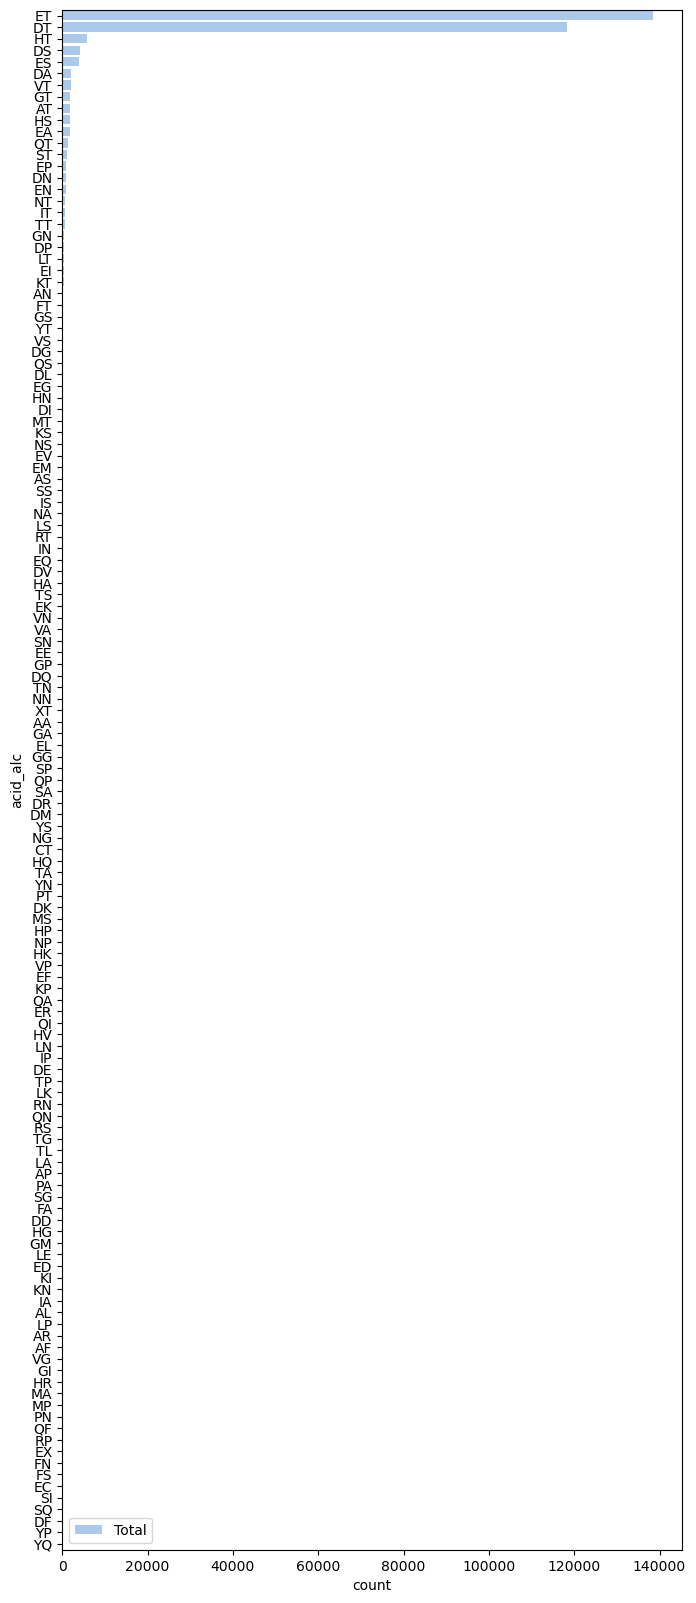

In [34]:
# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(8, 20))


sns.set_color_codes('pastel')
sns.barplot(x='count', 
            y='acid_alc', 
            data=count,
            label="Total", 
            color="b")

In [ ]:
sns.set_theme(style="whitegrid")

# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(6, 15))



NameError: name 'sns' is not defined